# 05 — RUL Regression & SHAP Explainability

**Goal:** Train a gradient-boosted tree model (XGBoost) to predict how many cycles remain before an engine fails — the Remaining Useful Life (RUL). Then use SHAP (SHapley Additive exPlanations) to explain *why* the model flags a specific engine as high risk.

**Why XGBoost for RUL regression?**
The LSTM autoencoder in the previous notebooks learned to detect *anomalies* — windows that look different from healthy behavior. XGBoost solves a different problem: given a snapshot of an engine right now, predict a continuous RUL number. Tree-based models handle tabular feature vectors very well, train fast, and are naturally compatible with SHAP, which is exactly the explainability format that defense and industrial operators require for human trust in model outputs.

**Inputs:** `X_features.npy` (110 features: 11 raw sensors + 99 rolling stats), `y_rul.npy`

**Outputs:**
- Trained XGBoost regressor → `models/xgb_rul.json`
- RUL predictions for every test window → `results/rul_predictions.csv`
- SHAP summary and waterfall plots → `results/`

## Step 1 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import os

import xgboost as xgb
import shap

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("XGBoost version:", xgb.__version__)
print("SHAP version:", shap.__version__)

XGBoost version: 3.2.0
SHAP version: 0.51.0


## Step 2 — Load Processed Features

We load the flat feature matrix produced in `02_preprocessing.ipynb`. Each row is a single engine cycle snapshot (taken at the end of a 30-cycle window), and contains:
- **11 raw normalized sensor readings** — the current state of each sensor
- **99 rolling statistics** — mean, standard deviation, and rate-of-change over the last 5, 10, and 30 cycles for each sensor

The target `y_rul` is the number of cycles remaining before that engine fails.

In [2]:
X          = np.load('../data/processed/X_features.npy')
y_rul      = np.load('../data/processed/y_rul.npy')
engine_ids = np.load('../data/processed/engine_ids_flat.npy')

with open('../data/processed/feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

print(f"X shape:       {X.shape}")
print(f"y_rul shape:   {y_rul.shape}")
print(f"RUL range:     {y_rul.min()} – {y_rul.max()} cycles")
print(f"Total engines: {len(np.unique(engine_ids))}")
print(f"Features:      {len(feature_cols)} ({11} raw + {len(feature_cols)-11} rolling)")

X shape:       (17731, 110)
y_rul shape:   (17731,)
RUL range:     0 – 332 cycles
Total engines: 100
Features:      110 (11 raw + 99 rolling)


## Step 3 — Engine-Aware Train / Test Split

A critical design decision: we split **by engine ID**, not by row index. This means the model is trained on engines 1–80 and tested on engines 81–100 — engines it has never seen before.

This is realistic. In deployment you train on historical fleet data and then apply the model to new engines as they come online. A random row split would leak time-series information across the boundary and give overly optimistic test scores.

In [3]:
all_engines   = np.unique(engine_ids)
train_engines = all_engines[:80]
test_engines  = all_engines[80:]

train_mask = np.isin(engine_ids, train_engines)
test_mask  = np.isin(engine_ids, test_engines)

X_train, y_train = X[train_mask], y_rul[train_mask]
X_test,  y_test  = X[test_mask],  y_rul[test_mask]
engine_ids_test  = engine_ids[test_mask]

print(f"Train: {X_train.shape[0]} windows from {len(train_engines)} engines")
print(f"Test:  {X_test.shape[0]} windows from {len(test_engines)} engines")

Train: 13818 windows from 80 engines
Test:  3913 windows from 20 engines


## Step 4 — Naive Baseline

Before training any model, we establish a **naive baseline**: always predict the mean RUL of the training set. This is the simplest possible predictor, and any real model must beat it to be worth using. Comparing against the baseline shows exactly how much value the model adds.

In [4]:
mean_rul       = y_train.mean()
baseline_preds = np.full_like(y_test, fill_value=mean_rul, dtype=float)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_mae  = mean_absolute_error(y_test, baseline_preds)

print(f"Naive baseline (always predict mean RUL = {mean_rul:.1f})")
print(f"  RMSE: {baseline_rmse:.2f} cycles")
print(f"  MAE:  {baseline_mae:.2f} cycles")

Naive baseline (always predict mean RUL = 90.8)
  RMSE: 72.30 cycles
  MAE:  57.96 cycles


## Step 5 — Train XGBoost Regressor

XGBoost builds an ensemble of decision trees sequentially — each new tree corrects the errors left by the previous ones. Key hyperparameters:

- **`n_estimators=1000`** — maximum number of trees; we use early stopping to avoid overfitting
- **`max_depth=6`** — how deep each tree can grow; controls model complexity
- **`learning_rate=0.05`** — how much each tree contributes; lower = more conservative, less overfitting
- **`subsample=0.8`** — each tree is trained on 80% of the data (randomly sampled), which adds regularization
- **`early_stopping_rounds=50`** — training stops if the validation score hasn't improved in 50 rounds

`eval_metric='rmse'` means we optimize Root Mean Square Error — appropriate for regression where large prediction errors should be penalized more than small ones.

In [5]:
model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=50,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-rmse:56.30016	validation_1-rmse:70.34289


[100]	validation_0-rmse:8.43078	validation_1-rmse:43.94231


[189]	validation_0-rmse:5.70837	validation_1-rmse:43.98805



Best iteration: 139


## Step 6 — Training Curve

The training curve shows how RMSE improved as more trees were added. The gap between train and validation RMSE tells us about overfitting — a small gap means the model generalizes well to unseen engines.

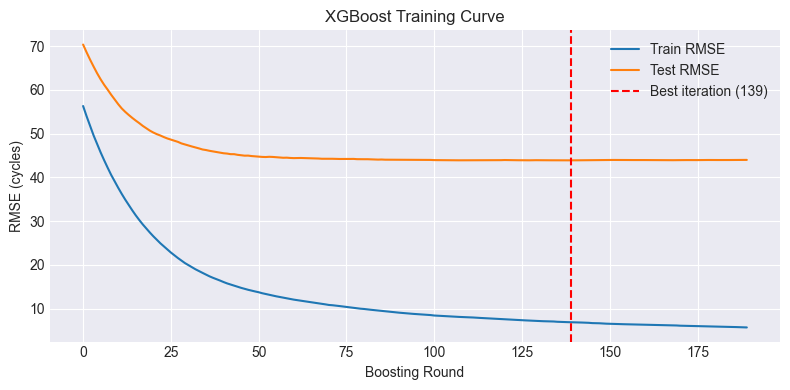

In [6]:
results = model.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse   = results['validation_1']['rmse']

plt.figure(figsize=(8, 4))
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse,   label='Test RMSE')
plt.axvline(model.best_iteration, color='red', linestyle='--',
            label=f'Best iteration ({model.best_iteration})')
plt.xlabel('Boosting Round')
plt.ylabel('RMSE (cycles)')
plt.title('XGBoost Training Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../results/xgb_training_curve.png', dpi=150)
plt.show()

## Step 7 — Regression Metrics vs Baseline

We evaluate on the held-out test engines using three metrics:

- **RMSE** (Root Mean Square Error) — average error in cycle units, penalising large misses more heavily
- **MAE** (Mean Absolute Error) — average absolute error in cycle units, easier to interpret
- **R²** — proportion of variance explained; 1.0 is perfect, 0.0 means the model is no better than the mean

In [7]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)  # RUL can't be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=== XGBoost vs Naive Baseline ===")
print(f"{'Metric':<8} {'Baseline':>12} {'XGBoost':>12} {'Improvement':>14}")
print("-" * 50)
print(f"{'RMSE':<8} {baseline_rmse:>12.2f} {rmse:>12.2f} {baseline_rmse - rmse:>+14.2f} cycles")
print(f"{'MAE':<8} {baseline_mae:>12.2f} {mae:>12.2f} {baseline_mae - mae:>+14.2f} cycles")
print(f"{'R²':<8} {'—':>12} {r2:>12.4f}")

=== XGBoost vs Naive Baseline ===
Metric       Baseline      XGBoost    Improvement
--------------------------------------------------
RMSE            72.30        43.88         +28.42 cycles
MAE             57.96        29.35         +28.61 cycles
R²                  —       0.6141


## Step 8 — Predicted vs Actual RUL

A scatter plot of predicted vs actual RUL is the clearest way to see where the model struggles. Points along the diagonal are perfect predictions. The spread around the diagonal shows the prediction error. We expect the model to perform well at high RUL (engines are in a stable healthy state) but to struggle more at low RUL where degradation becomes rapid and noisy.

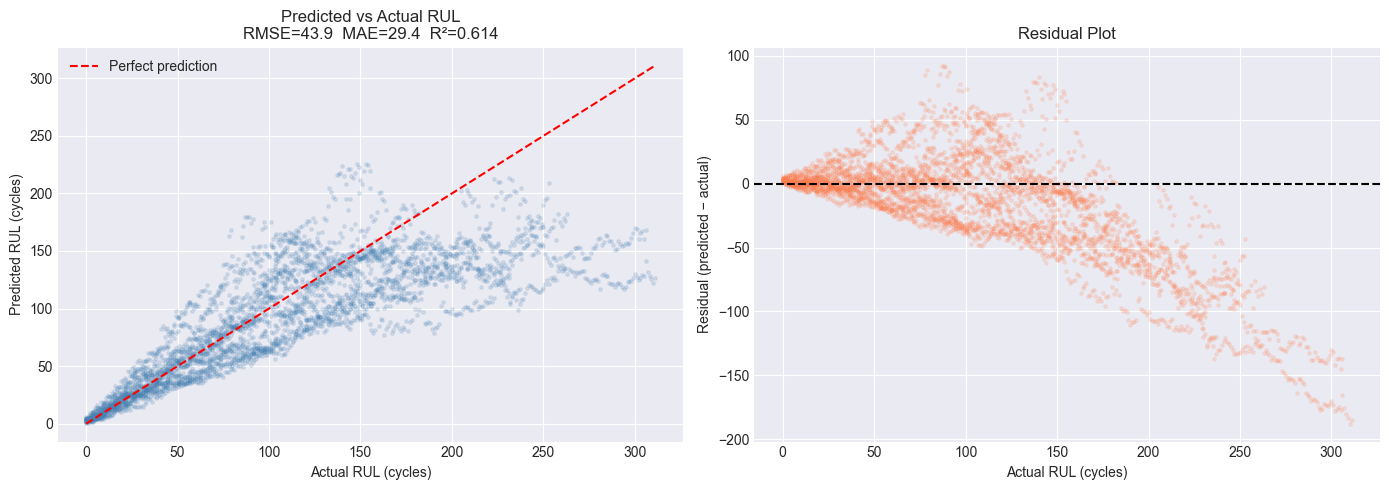

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.15, s=6, c='steelblue')
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title(f'Predicted vs Actual RUL\nRMSE={rmse:.1f}  MAE={mae:.1f}  R²={r2:.3f}')
ax.legend()

# Residuals
residuals = y_pred - y_test
ax = axes[1]
ax.scatter(y_test, residuals, alpha=0.15, s=6, c='coral')
ax.axhline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (predicted − actual)')
ax.set_title('Residual Plot')

plt.tight_layout()
plt.savefig('../results/rul_scatter.png', dpi=150)
plt.show()

## Step 9 — Per-Engine RUL Timeline

Instead of looking at all windows at once, we trace RUL over time for individual engines. This is the most intuitive view for operators: a line that should decline toward zero as the engine approaches failure. When the predicted line closely tracks the actual line, the model is giving actionable early warning. We also shade the high-risk zone (RUL < 30 cycles) in red.

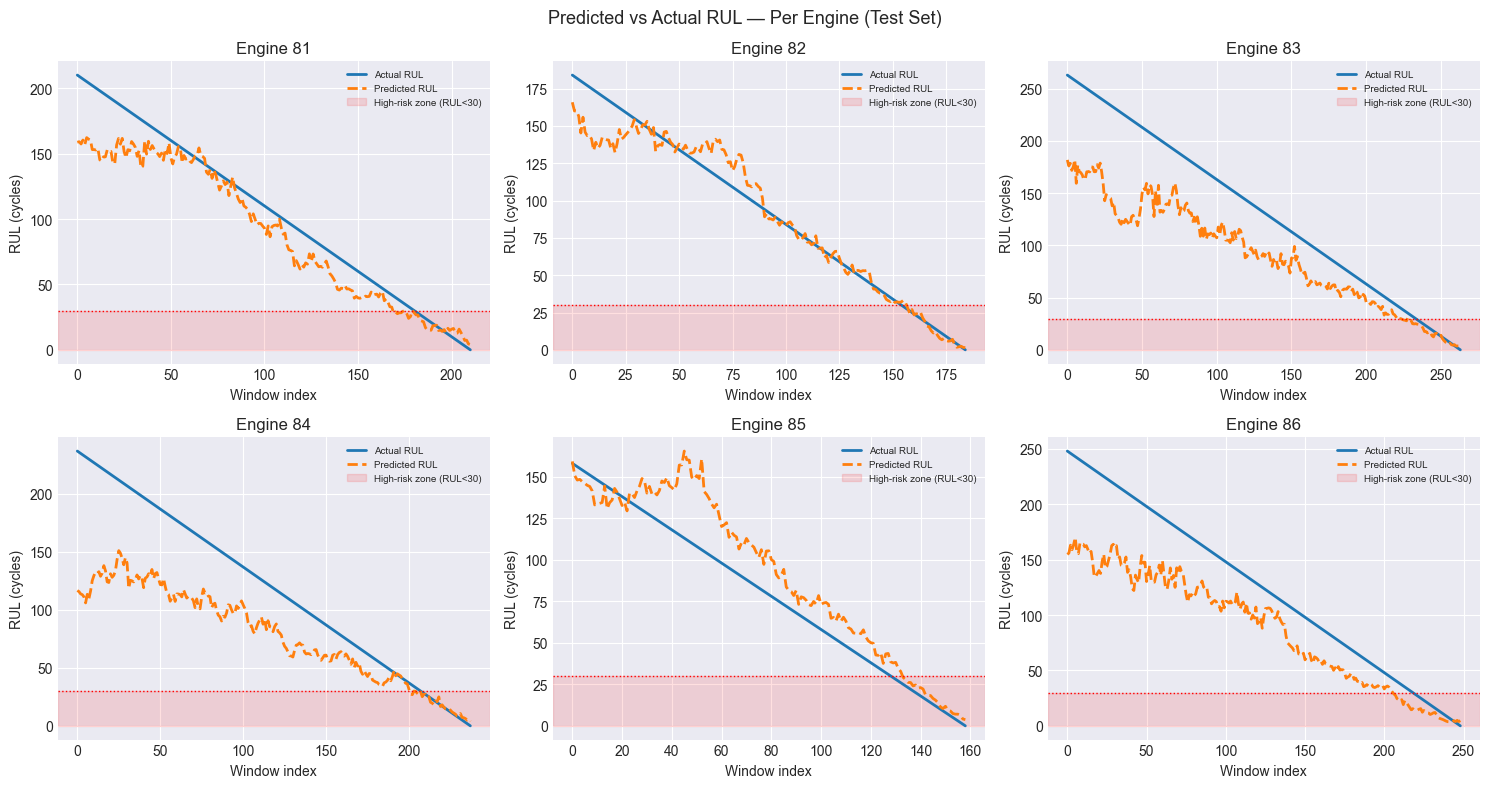

In [9]:
sample_engines = test_engines[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, eng in zip(axes.flat, sample_engines):
    mask       = engine_ids_test == eng
    actual     = y_test[mask]
    predicted  = y_pred[mask]
    cycles     = np.arange(len(actual))

    ax.plot(cycles, actual,    label='Actual RUL',    lw=2)
    ax.plot(cycles, predicted, label='Predicted RUL', lw=2, linestyle='--')
    ax.axhspan(0, 30, alpha=0.12, color='red', label='High-risk zone (RUL<30)')
    ax.axhline(30, color='red', linestyle=':', lw=1)
    ax.set_title(f'Engine {int(eng)}')
    ax.set_xlabel('Window index')
    ax.set_ylabel('RUL (cycles)')
    ax.legend(fontsize=7)

plt.suptitle('Predicted vs Actual RUL — Per Engine (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/rul_timelines.png', dpi=150)
plt.show()

## Step 10 — Binary HIGH RISK Alert

RUL regression gives a continuous number, but operators often need a simple binary decision: **is this engine safe or high risk?** We convert the RUL prediction into a binary alert by thresholding at 30 cycles — matching the failure window we defined during preprocessing.

This effectively turns the regression output into a classifier. The classification report tells us how well this alert performs at catching engines that are genuinely within 30 cycles of failure.

=== HIGH RISK Alert Performance (RUL < 30 cycles) ===
[[3235   78]
 [  69  531]]

              precision    recall  f1-score   support

        Safe       0.98      0.98      0.98      3313
   HIGH RISK       0.87      0.89      0.88       600

    accuracy                           0.96      3913
   macro avg       0.93      0.93      0.93      3913
weighted avg       0.96      0.96      0.96      3913



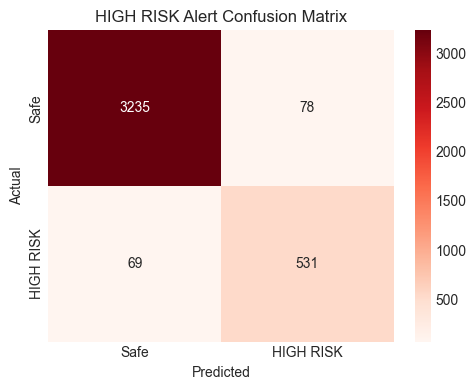

In [10]:
ALERT_THRESHOLD = 30

y_true_bin = (y_test  < ALERT_THRESHOLD).astype(int)
y_pred_bin = (y_pred  < ALERT_THRESHOLD).astype(int)

print("=== HIGH RISK Alert Performance (RUL < 30 cycles) ===")
print(confusion_matrix(y_true_bin, y_pred_bin))
print()
print(classification_report(y_true_bin, y_pred_bin, target_names=['Safe', 'HIGH RISK']))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Safe', 'HIGH RISK'],
            yticklabels=['Safe', 'HIGH RISK'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('HIGH RISK Alert Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/alert_confusion_matrix.png', dpi=150)
plt.show()

## Step 11 — SHAP Explainability

SHAP (SHapley Additive exPlanations) answers the question: **for this specific prediction, which features pushed the RUL estimate up or down, and by how much?**

SHAP is rooted in cooperative game theory — each feature is given a "credit" for the final prediction based on its average marginal contribution across all possible feature orderings. This gives a mathematically fair attribution that:
- Is **consistent** — a more important feature always gets a higher SHAP value
- Is **local** — values are specific to each individual prediction, not global averages
- Is **model-agnostic** in principle, but for tree models like XGBoost, SHAP values are computed exactly and very efficiently using the TreeExplainer

For defense and industrial applications, SHAP satisfies the explainability requirement: an operator can see exactly which sensor trend drove a HIGH RISK flag and decide whether to trust the alert.

In [11]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("One SHAP value per (window, feature) — same shape as X_test")

SHAP values shape: (3913, 110)
One SHAP value per (window, feature) — same shape as X_test


### SHAP Summary Plot — Global Feature Importance

The summary plot shows all features ranked by their average impact on the model's RUL predictions. Each dot is one window. Color shows the feature value (red = high, blue = low). The horizontal position shows whether that value pushed the predicted RUL higher (right) or lower (left). Features at the top matter most to the model overall.

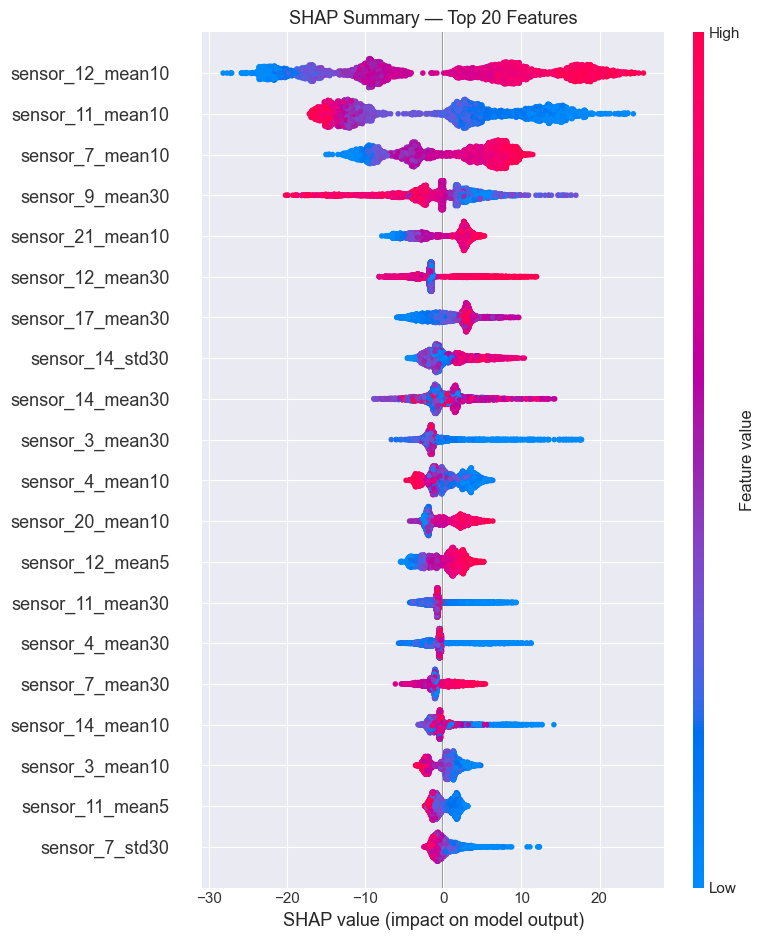

In [12]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_cols,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Top 20 Features', fontsize=13)
plt.tight_layout()
plt.savefig('../results/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP Waterfall Plot — Why Is This Engine Flagged?

The waterfall plot zooms into a **single prediction** for one HIGH RISK window. It shows the model's baseline prediction (average RUL across training data) and then each feature's contribution as a step — red bars push the prediction lower (toward failure), blue bars push it higher (toward safe). The final bar lands on the model's output.

This is the plot you would show an operator who asks: *"Why is Engine #X flagged as high risk?"*

Window index: 181
  Actual RUL:    29 cycles
  Predicted RUL: 26.7 cycles  → HIGH RISK


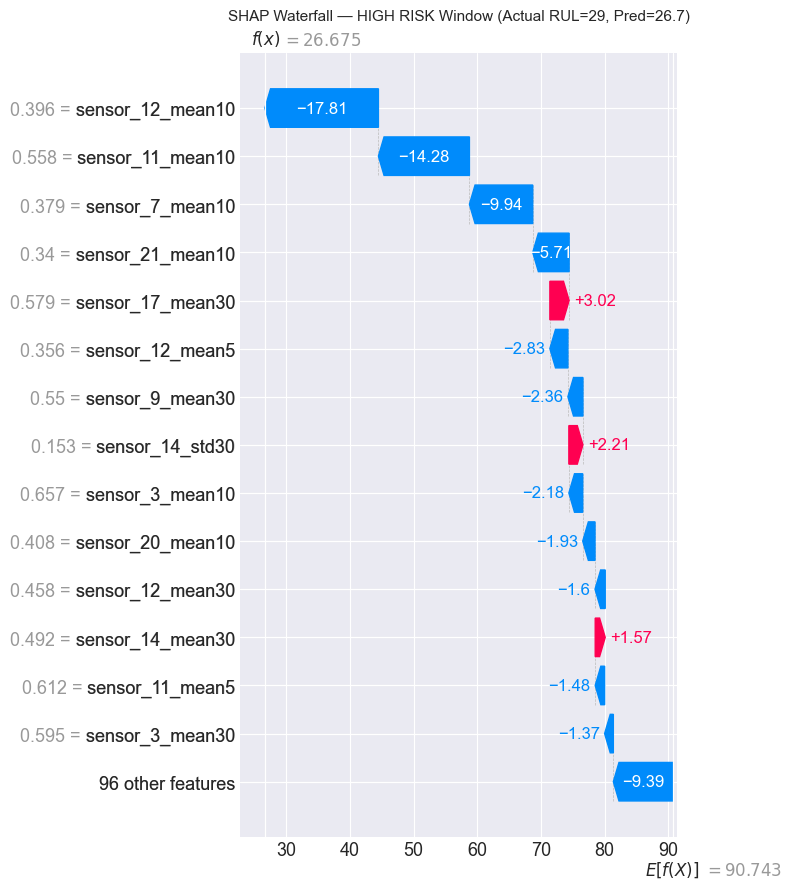

In [13]:
# Pick the first test window where the model correctly predicts HIGH RISK
correctly_flagged = np.where((y_pred_bin == 1) & (y_true_bin == 1))[0]
idx = correctly_flagged[0]

print(f"Window index: {idx}")
print(f"  Actual RUL:    {y_test[idx]:.0f} cycles")
print(f"  Predicted RUL: {y_pred[idx]:.1f} cycles  → HIGH RISK")

shap_exp = shap.Explanation(
    values         = shap_values[idx],
    base_values    = explainer.expected_value,
    data           = X_test[idx],
    feature_names  = feature_cols
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — HIGH RISK Window (Actual RUL={y_test[idx]:.0f}, Pred={y_pred[idx]:.1f})', fontsize=11)
plt.tight_layout()
plt.savefig('../results/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Save Artifacts

In [14]:
# Save model
model.save_model('../models/xgb_rul.json')
print("Model saved → models/xgb_rul.json")

# Save predictions
pred_df = pd.DataFrame({
    'engine_id':   engine_ids_test,
    'actual_rul':  y_test,
    'pred_rul':    y_pred.round(1),
    'high_risk':   y_pred_bin,
    'true_risk':   y_true_bin
})
pred_df.to_csv('../results/rul_predictions.csv', index=False)
print("Predictions saved → results/rul_predictions.csv")
pred_df.head(10)

Model saved → models/xgb_rul.json
Predictions saved → results/rul_predictions.csv


,engine_id,actual_rul,pred_rul,high_risk,true_risk
0,81,210,158.699997,0,0
1,81,209,159.100006,0,0
2,81,208,157.300003,0,0
3,81,207,160.399994,0,0
4,81,206,156.899994,0,0
5,81,205,162.199997,0,0
6,81,204,161.000000,0,0
7,81,203,160.399994,0,0
8,81,202,153.000000,0,0
9,81,201,153.100006,0,0


## Summary

| Item | Value |
|---|---|
| Model | XGBoost Regressor |
| Features | 110 (11 raw + 99 rolling stats) |
| Train engines | 80 |
| Test engines | 20 |
| Test RMSE | *(run to populate)* |
| Test MAE | *(run to populate)* |
| Test R² | *(run to populate)* |
| Improvement over baseline (MAE) | *(run to populate)* |

**Artifacts saved:**
- `models/xgb_rul.json` — trained XGBoost model
- `results/rul_predictions.csv` — per-window predictions with risk labels
- `results/xgb_training_curve.png`
- `results/rul_scatter.png`
- `results/rul_timelines.png`
- `results/alert_confusion_matrix.png`
- `results/shap_summary.png`
- `results/shap_waterfall.png`

**Next:** `06_api.ipynb` — FastAPI inference endpoint that accepts a live sensor window and returns RUL + risk level + top SHAP features.